
# Insurance Claims Fraud Detection - EDA & Feature Engineering





In [1]:
# =========================================
# LOAD CLEANED TABLES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('customers_cleaned.csv')

policies = pd.read_csv('policies_cleaned.csv')

claims = pd.read_csv(
    'claims_cleaned.csv',
    parse_dates=[
        'claim_submission_date',
        'incident_date'
    ]
)

payments = pd.read_csv('payments_cleaned.csv')

providers = pd.read_csv('providers_cleaned.csv')

agents = pd.read_csv('agents_cleaned.csv')

claim_investigations = pd.read_csv(
    'claim_investigations_cleaned.csv'
)

policy_renewals = pd.read_csv(
    'policy_renewals_cleaned.csv'
)

customer_complaints = pd.read_csv(
    'customer_complaints_cleaned.csv'
)

branches = pd.read_csv('branches_cleaned.csv')

## Basic Dataset Information

Explanation of analysis and business insights.

In [2]:

# Dataset Shapes
print("Claims:", claims.shape)
print("Customers:", customers.shape)
print("Policies:", policies.shape)

# Data Types
claims.info()


Claims: (151014, 11)
Customers: (100001, 10)
Policies: (167178, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151014 entries, 0 to 151013
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   claim_id               151014 non-null  int64         
 1   policy_id              151014 non-null  int64         
 2   customer_id            151014 non-null  float64       
 3   claim_type             151014 non-null  object        
 4   claim_amount           151014 non-null  float64       
 5   claim_submission_date  151014 non-null  datetime64[ns]
 6   incident_date          151014 non-null  datetime64[ns]
 7   claim_status           151014 non-null  object        
 8   fraud_flag             151014 non-null  int64         
 9   settlement_days        151014 non-null  int64         
 10  provider_id            151014 non-null  int64         
dtypes: datetime64[ns](2), float64(2), in

## Total Policies, Claims, Approval Rate, Rejection Rate, Fraud Rate

Explanation of analysis and business insights.

In [3]:

total_policies = claims['policy_id'].nunique()
total_claims = claims['claim_id'].nunique()

approval_rate = (
    (claims['claim_status'] == 'Approved').mean() * 100
)

rejection_rate = (
    (claims['claim_status'] == 'Rejected').mean() * 100
)

fraud_rate = (
    (claims['fraud_flag'] == 1).mean() * 100
)

print("Total Policies:", total_policies)
print("Total Claims:", total_claims)
print("Approval Rate:", round(approval_rate,2), "%")
print("Rejection Rate:", round(rejection_rate,2), "%")
print("Fraud Rate:", round(fraud_rate,2), "%")


Total Policies: 112276
Total Claims: 151014
Approval Rate: 24.83 %
Rejection Rate: 24.83 %
Fraud Rate: 12.22 %


## Claim Amount Trends by Month

Explanation of analysis and business insights.

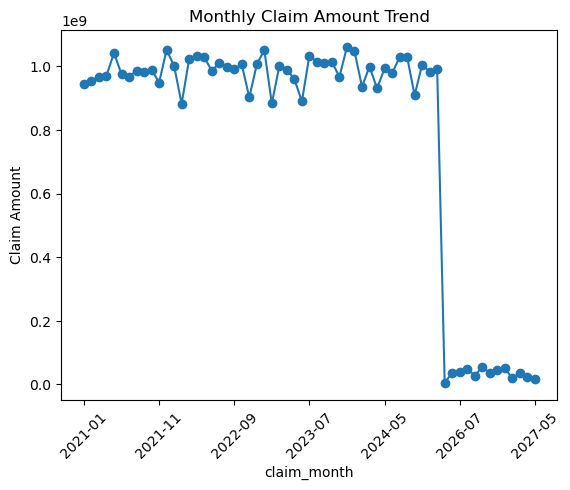

In [4]:

claims['claim_month'] = (
    claims['claim_submission_date']
    .dt.to_period('M')
    .astype(str)
)

monthly_claims = (
    claims.groupby('claim_month')['claim_amount']
    .sum()
)

monthly_claims.plot(marker='o')
plt.title("Monthly Claim Amount Trend")
plt.ylabel("Claim Amount")
plt.xticks(rotation=45)
plt.show()


## Fraud Claims by City, Branch, Policy Type, Agent, Provider

Explanation of analysis and business insights.

city
Noida          958
Kochi          942
Gurugram       941
Pune           928
Ranchi         918
Patna          918
Nagpur         916
Bhubaneswar    914
Mumbai         911
Chandigarh     910
Name: claim_id, dtype: int64


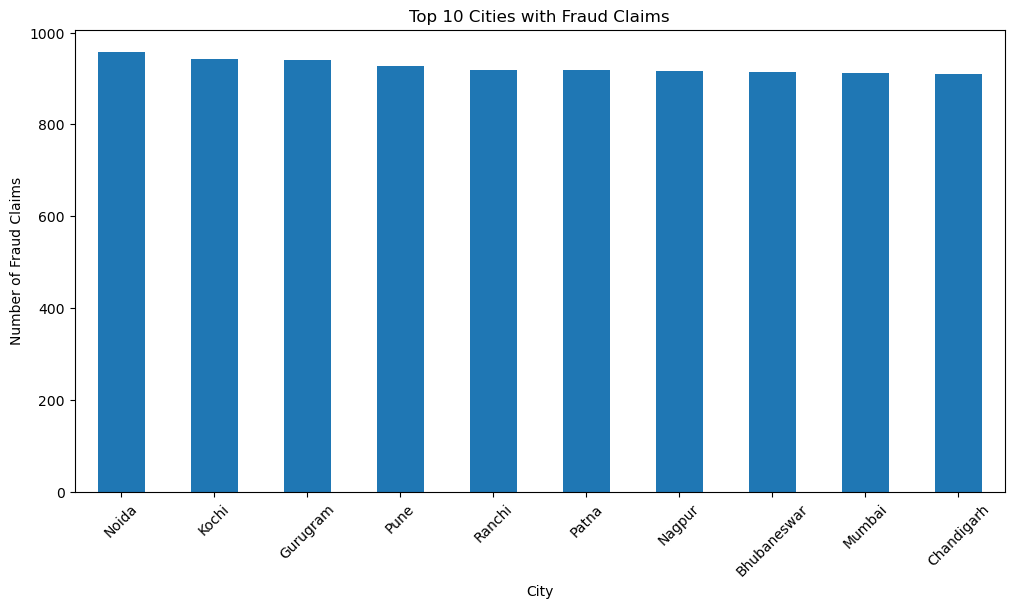

In [5]:
# Merge claims with customers

claims_city = claims.merge(
    customers[['customer_id', 'city']],
    on='customer_id',
    how='left'
)

# Fraud Claims by City

fraud_city = (
    claims_city[claims_city['fraud_flag'] == 1]
    .groupby('city')['claim_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(fraud_city)

# Visualization
plt.figure(figsize=(12,6))
fraud_city.plot(kind='bar')

plt.title('Top 10 Cities with Fraud Claims')
plt.xlabel('City')
plt.ylabel('Number of Fraud Claims')

plt.xticks(rotation=45)
plt.show()

branch_name
Surat Branch-40      42
Ranchi Branch-219    40
Surat Branch-200     38
Jaipur Branch-230    38
Chennai Branch-46    38
Noida Branch-56      37
Mumbai Branch-154    37
Jaipur Branch-110    37
Kochi Branch-231     36
Chennai Branch-6     36
Name: claim_id, dtype: int64


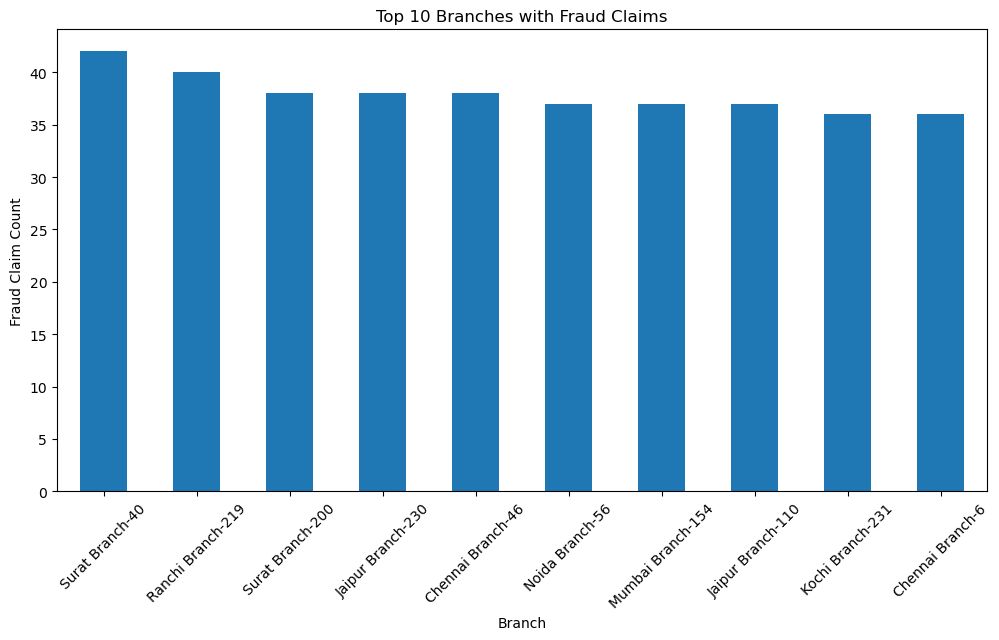

In [6]:
# Merge claims with branches

claims_branch = claims.merge(
    policies[['policy_id', 'branch_id']],
    on='policy_id',
    how='left'
)

claims_branch = claims_branch.merge(
    branches[['branch_id', 'branch_name']],
    on='branch_id',
    how='left'
)

# Fraud Analysis by Branch
fraud_branch = (
    claims_branch[claims_branch['fraud_flag'] == 1]
    .groupby('branch_name')['claim_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(fraud_branch)

# Visualization
plt.figure(figsize=(12,6))
fraud_branch.plot(kind='bar')
plt.title('Top 10 Branches with Fraud Claims')
plt.xlabel('Branch')
plt.ylabel('Fraud Claim Count')
plt.xticks(rotation=45)
plt.show()

policy_type
Health      2563
Motor       2527
Property    2450
Life        2420
Travel      2370
Name: claim_id, dtype: int64


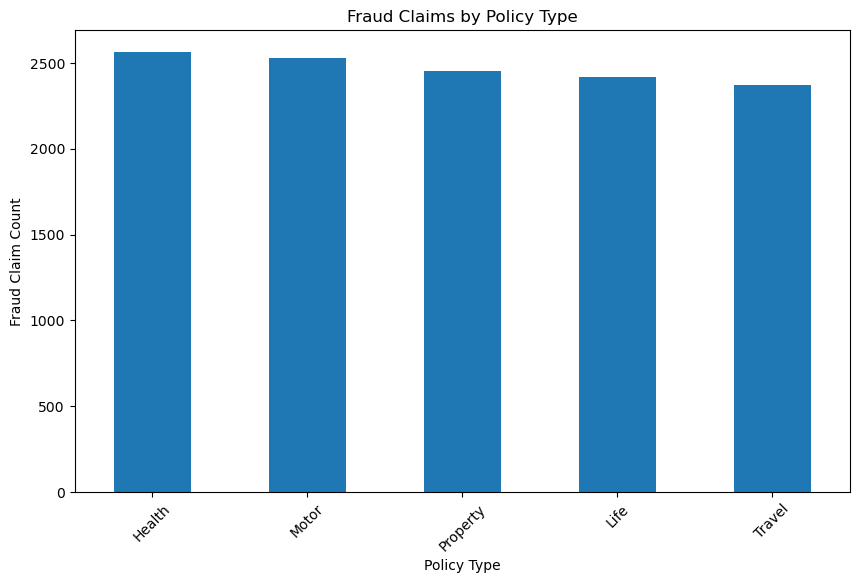

In [7]:
# Merge claims with policies

claims_policy = claims.merge(
    policies[['policy_id', 'policy_type']],
    on='policy_id',
    how='left'
)

# Fraud Analysis by Policy Type
fraud_policy = (
    claims_policy[claims_policy['fraud_flag'] == 1]
    .groupby('policy_type')['claim_id']
    .count()
    .sort_values(ascending=False)
)

print(fraud_policy)

# Visualization
plt.figure(figsize=(10,6))
fraud_policy.plot(kind='bar')
plt.title('Fraud Claims by Policy Type')
plt.xlabel('Policy Type')
plt.ylabel('Fraud Claim Count')
plt.xticks(rotation=45)
plt.show()

agent_name
Unknown              257
Amit Patel_7383        7
Sneha Kumar_14008      7
Amit Sharma_14802      7
Rahul Iyer_14251       7
Ravi Das_9515          7
Rahul Das_15322        6
Ravi Reddy_11071       6
Neha Gupta_8293        6
Neha Patel_16646       6
Name: claim_id, dtype: int64


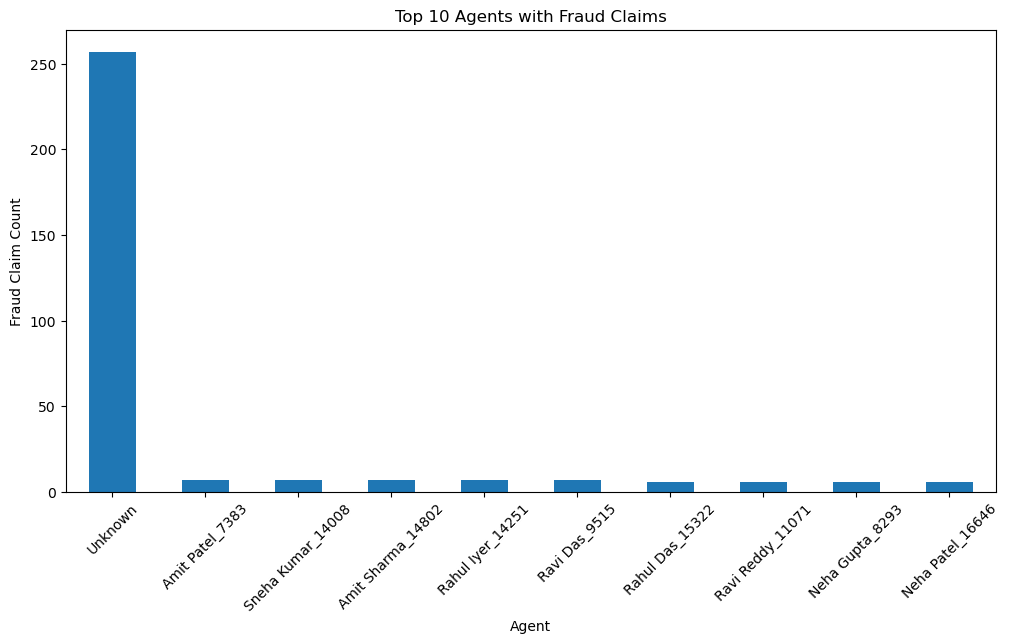

In [8]:
# Merge claims with policies to get agent_id

claims_agent = claims.merge(
    policies[['policy_id', 'agent_id']],
    on='policy_id',
    how='left'
)

# Merge with agents table

claims_agent = claims_agent.merge(
    agents[['agent_id', 'agent_name']],
    on='agent_id',
    how='left'
)

# Fraud Analysis by Agent

fraud_agent = (
    claims_agent[claims_agent['fraud_flag'] == 1]
    .groupby('agent_name')['claim_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(fraud_agent)

# Visualization

plt.figure(figsize=(12,6))

fraud_agent.plot(kind='bar')

plt.title('Top 10 Agents with Fraud Claims')
plt.xlabel('Agent')
plt.ylabel('Fraud Claim Count')

plt.xticks(rotation=45)

plt.show()

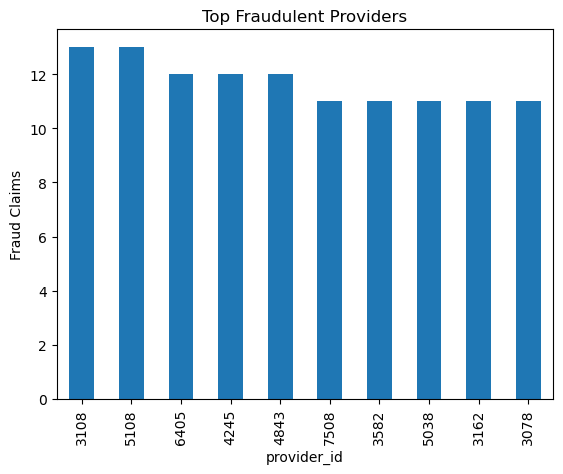

In [9]:

fraud_claims = claims[claims['fraud_flag'] == 1]

fraud_provider = (
    fraud_claims.groupby('provider_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

fraud_provider.plot(kind='bar')
plt.title("Top Fraudulent Providers")
plt.ylabel("Fraud Claims")
plt.show()


## Claim Amount Distribution and Outlier Detection

Explanation of analysis and business insights.

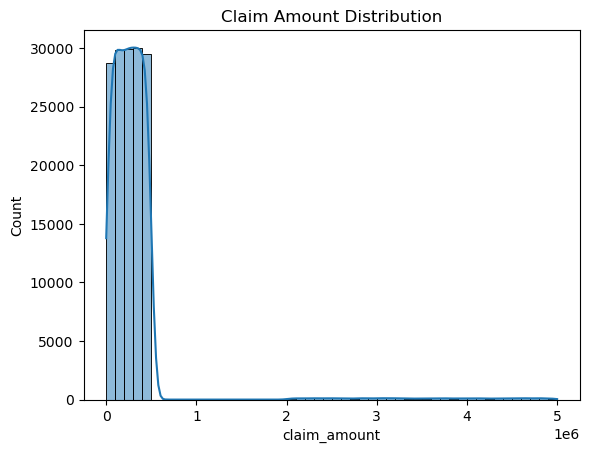

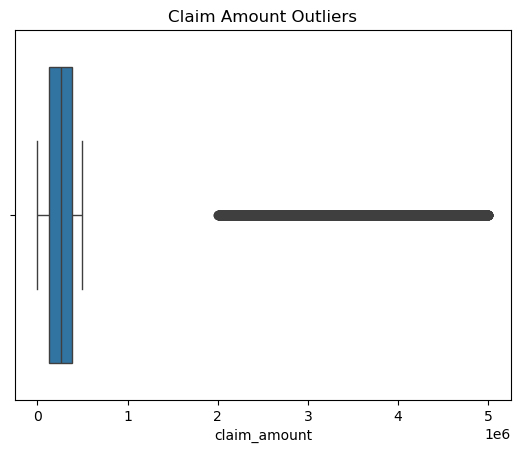

In [10]:

sns.histplot(claims['claim_amount'], bins=50, kde=True)
plt.title("Claim Amount Distribution")
plt.show()

sns.boxplot(x=claims['claim_amount'])
plt.title("Claim Amount Outliers")
plt.show()


## Settlement Time Distribution and Pending Claims

Explanation of analysis and business insights.

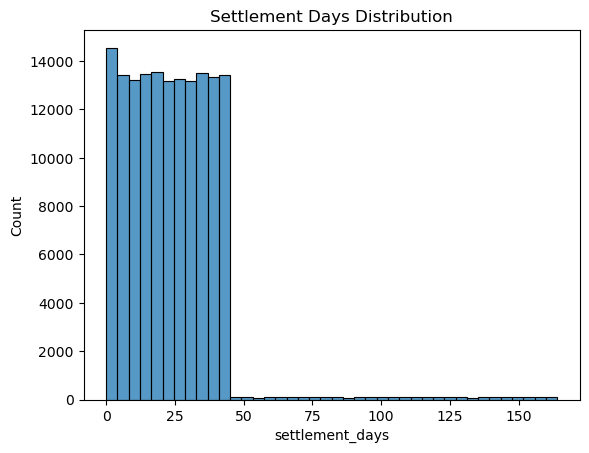

Pending Claims: 38438


In [11]:

sns.histplot(claims['settlement_days'], bins=40)
plt.title("Settlement Days Distribution")
plt.show()

pending_claims = claims[claims['claim_status'] == 'Pending']
print("Pending Claims:", pending_claims.shape[0])


## Customer Age/Income/Risk vs Claim Behavior

Explanation of analysis and business insights.

age
10.0    302319.488839
18.0    310306.985041
19.0    325955.521186
20.0    336786.280052
21.0    306951.152450
Name: claim_amount, dtype: float64


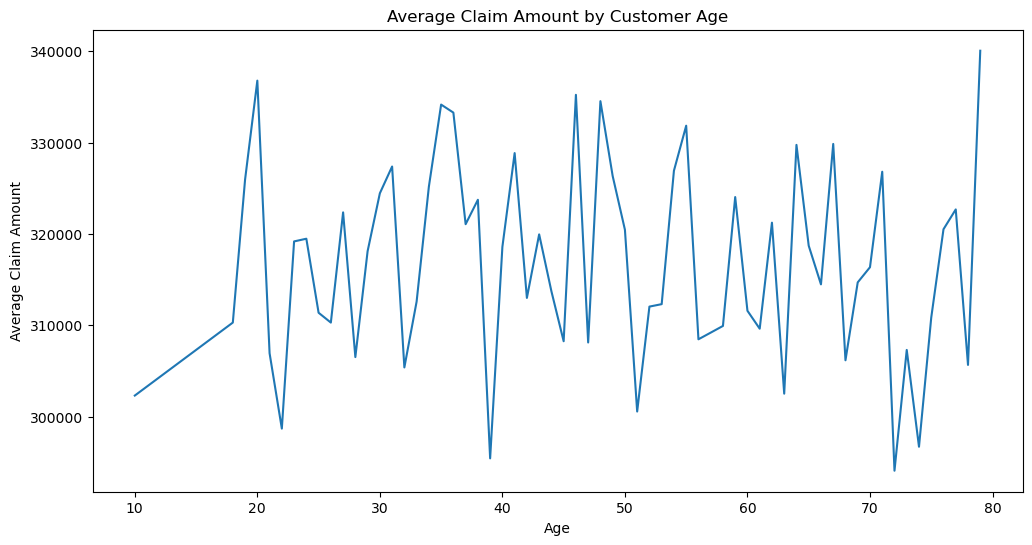

In [12]:
# Merge claims with customers

claims_age = claims.merge(
    customers[['customer_id', 'age']],
    on='customer_id',
    how='left'
)

# Average Claim Amount by Age

age_claim = (
    claims_age.groupby('age')['claim_amount']
    .mean()
    .sort_index()
)

print(age_claim.head())

# Visualization

plt.figure(figsize=(12,6))

plt.plot(age_claim.index, age_claim.values)

plt.title('Average Claim Amount by Customer Age')
plt.xlabel('Age')
plt.ylabel('Average Claim Amount')

plt.show()

annual_income
0.19     58739.390
0.26    218148.065
0.38    170286.170
0.60    121001.670
0.64    379285.750
Name: claim_amount, dtype: float64


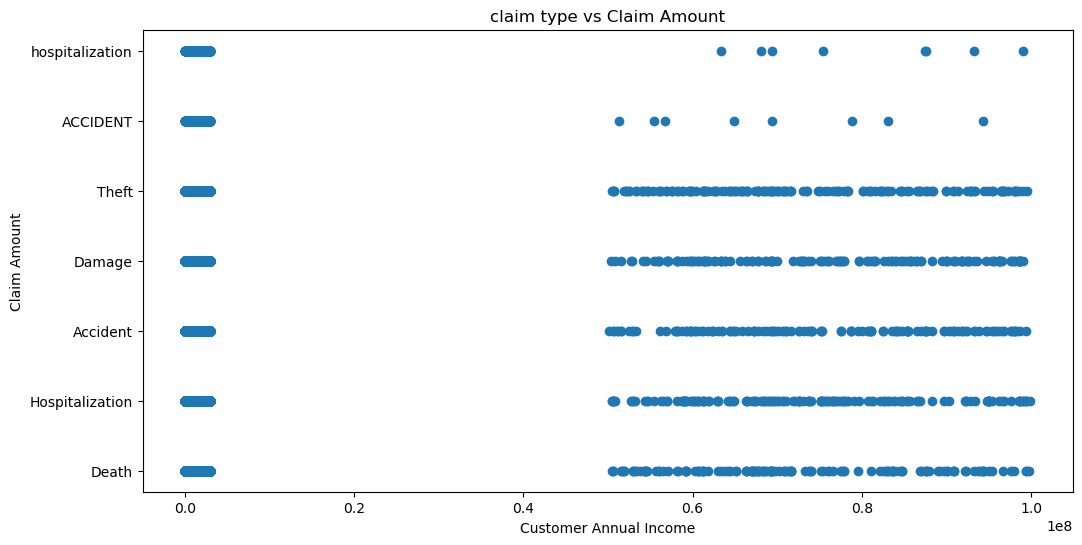

In [13]:
# Merge claims with customer income

claims_income = claims.merge(
    customers[['customer_id', 'annual_income']],
    on='customer_id',
    how='left'
)

# Average Claim Amount by Income

income_claim = (
    claims_income.groupby('annual_income')['claim_amount']
    .mean()
    .sort_index()
)

print(income_claim.head())

# Scatter Plot

plt.figure(figsize=(12,6))

plt.scatter(
    claims_income['annual_income'],
    claims_income['claim_type']
)

plt.title('claim type vs Claim Amount')
plt.xlabel('Customer Annual Income')
plt.ylabel('Claim Amount')

plt.show()

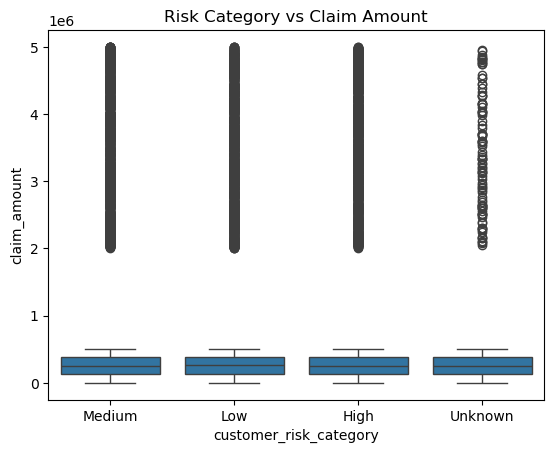

In [14]:

customer_claims = claims.merge(
    customers,
    on='customer_id',
    how='left'
)

sns.boxplot(
    x='customer_risk_category',
    y='claim_amount',
    data=customer_claims
)

plt.title("Risk Category vs Claim Amount")
plt.show()


## Provider Risk Analysis and Inflated Billing

Explanation of analysis and business insights.

In [15]:

provider_analysis = (
    claims.groupby('provider_id')['claim_amount']
    .agg(['count','mean','sum'])
    .sort_values(by='mean', ascending=False)
)

print(provider_analysis.head(10))


             count           mean          sum
provider_id                                   
3949            25  826851.714400  20671292.86
6647            22  810256.075455  17825633.66
6436            22  806601.169091  17745225.72
7392            20  789649.440000  15792988.80
4310            30  754906.891000  22647206.73
3856            36  742426.519444  26727354.70
3736            37  737244.023514  27278028.87
6085            30  733436.712667  22003101.38
4633            35  732149.073714  25625217.58
6801            26  715662.398462  18607222.36


## Agent-wise Claim Ratio and Suspicious Policy Behavior

Explanation of analysis and business insights.

In [16]:

agent_claims = (
    claims.groupby('policy_id')
    .size()
    .reset_index(name='claim_count')
)

suspicious = agent_claims[agent_claims['claim_count'] > 3]

print(suspicious.head())


     policy_id  claim_count
342    5000835            4
370    5000907            4
445    5001077            4
461    5001102            4
588    5001378            4


## Complaint Categories vs Settlement Delays

Explanation of analysis and business insights.

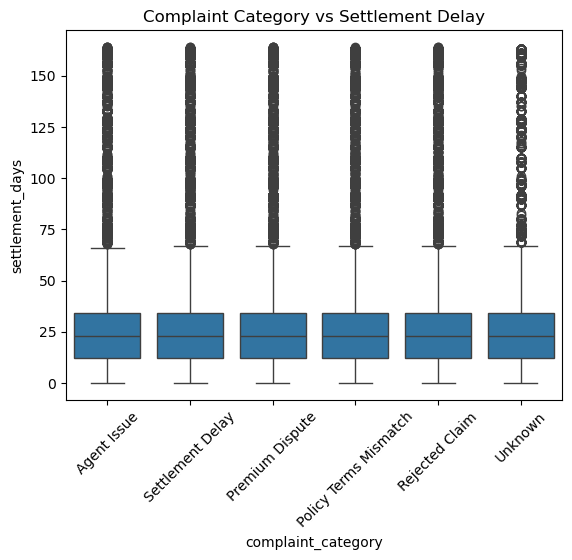

In [17]:

complaint_analysis = customer_complaints.merge(
    claims,
    on='customer_id',
    how='left'
)

sns.boxplot(
    x='complaint_category',
    y='settlement_days',
    data=complaint_analysis
)

plt.xticks(rotation=45)
plt.title("Complaint Category vs Settlement Delay")
plt.show()


## Renewal Behavior after Claims and Complaints

Explanation of analysis and business insights.

In [18]:

renewal_analysis = policies.merge(
    claims,
    on='policy_id',
    how='left'
)

renewal_analysis.groupby(
    'policy_status'
)['claim_amount'].mean()


policy_status
Active       315439.100764
Cancelled    317904.370495
Expired      312716.046362
Lapsed       320327.535442
Name: claim_amount, dtype: float64

## Fraud vs Non-Fraud Comparative Analysis

Explanation of analysis and business insights.

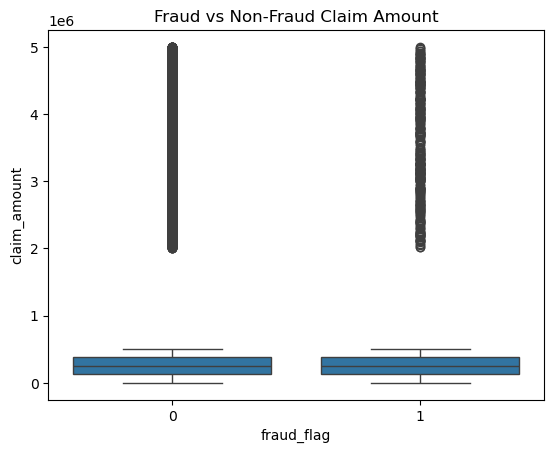

In [19]:

sns.boxplot(
    x='fraud_flag',
    y='claim_amount',
    data=claims
)

plt.title("Fraud vs Non-Fraud Claim Amount")
plt.show()
